# 🚨 Mission 2: 신고자 vs 119대원 음성 분류기 구축 (학습 전/후 비교 버전)

이 노트북은 AI가 아무것도 모를 때(학습 전)와, 똑똑해졌을 때(학습 후) 어떻게 대답이 달라지는지 눈으로 비교해보기 위해 구성되었습니다.

In [5]:
import os
import json
import random
import librosa
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'사용 중인 디바이스: {device}')

사용 중인 디바이스: cuda


In [6]:
class SpeakerDataset(Dataset):
    def __init__(self, label_dir, audio_dir, max_time_steps=256, is_train=True):
        self.audio_dir = audio_dir
        self.max_time_steps = max_time_steps
        self.is_train = is_train
        self.samples = []
        
        for json_name in os.listdir(label_dir):
            if not json_name.endswith('.json'): continue
            
            json_path = os.path.join(label_dir, json_name)
            with open(json_path, 'r', encoding='utf-8') as f:
                data = json.load(f)
                
            wav_name = json_name.replace('.json', '.wav')
            wav_path = os.path.join(audio_dir, wav_name)
            if not os.path.exists(wav_path): continue
                
            for utt in data.get('utterances', []):
                self.samples.append({
                    'wav_path': wav_path,
                    'start_ms': utt['startAt'],
                    'end_ms': utt['endAt'],
                    'label': utt['speaker']
                })
                
    def __len__(self):
        return len(self.samples)
    
    def __getitem__(self, idx):
        sample = self.samples[idx]
        sr = 16000
        
        y, _ = librosa.load(sample['wav_path'], sr=sr)
        start_sample = int((sample['start_ms'] / 1000.0) * sr)
        end_sample = int((sample['end_ms'] / 1000.0) * sr)
        cut_audio = y[start_sample:end_sample]
        
        mel_spec = librosa.feature.melspectrogram(y=cut_audio, sr=sr, n_mels=128)
        mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
        
        current_length = mel_spec_db.shape[1]
        if current_length < self.max_time_steps:
            pad_width = self.max_time_steps - current_length
            mel_spec_db = np.pad(mel_spec_db, ((0, 0), (0, pad_width)), mode='constant')
        elif current_length > self.max_time_steps:
            if self.is_train:
                start_idx = random.randint(0, current_length - self.max_time_steps)
            else:
                start_idx = (current_length - self.max_time_steps) // 2
            mel_spec_db = mel_spec_db[:, start_idx : start_idx + self.max_time_steps]
            
        mel_tensor = torch.tensor(mel_spec_db, dtype=torch.float32).unsqueeze(0)
        label_tensor = torch.tensor(sample['label'], dtype=torch.float32)
        
        return mel_tensor, label_tensor


In [7]:
class AudioResNet(nn.Module):
    def __init__(self):
        super(AudioResNet, self).__init__()
        self.model = models.resnet50(pretrained=True)
        old_conv = self.model.conv1
        self.model.conv1 = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.model.conv1.weight.data = old_conv.weight.data.mean(dim=1, keepdim=True)
        num_ftrs = self.model.fc.in_features
        self.model.fc = nn.Linear(num_ftrs, 1)
        
    def forward(self, x):
        return self.model(x)


## 🛠️ 모델 생성 및 테스트용 데이터 뽑아놓기

비교를 위해 데이터 4문제를 딱 하나 골라서 `test_batch`로 고정해 둡니다.

In [8]:
BATCH_SIZE = 32
train_dataset = SpeakerDataset(label_dir='../data/train/label', audio_dir='../data/train/audio', is_train=True)
val_dataset = SpeakerDataset(label_dir='../data/val/label', audio_dir='../data/val/audio', is_train=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# 학습 전후 비교를 위해 검증 데이터에서 무작위로 딱 하나(1 Batch)만 미리 뽑아둡니다.
test_batch_x, test_batch_y = next(iter(val_loader))
test_batch_x = test_batch_x[:4].to(device)  # 4문제만 고정
test_batch_y = test_batch_y[:4].to(device)

model = AudioResNet().to(device)

def show_predictions(model, batch_x, batch_y, title_prefix=""):
    model.eval()
    with torch.no_grad():
        outputs = model(batch_x)
        # sigmoid 적용 후 0.5 이상이면 1(신고자), 미만이면 0(대원)
        preds = torch.round(torch.sigmoid(outputs)).squeeze(-1)
    
    plt.figure(figsize=(16, 4))
    for i in range(4):
        plt.subplot(1, 4, i + 1)
        img = batch_x[i].cpu().squeeze(0).numpy()
        actual = int(batch_y[i].item())
        predicted = int(preds[i].item())
        
        plt.imshow(img, cmap='viridis', origin='lower', aspect='auto')
        # 정답과 AI의 예측이 맞으면 파란색, 틀리면 빨간색으로 표시
        color = 'blue' if actual == predicted else 'red'
        
        title = f"[Actual] {'Caller' if actual==1 else 'Agent'}\n[{title_prefix}] {'Caller' if predicted==1 else 'Agent'}"
        plt.title(title, color=color, fontweight='bold')
        plt.xlabel('Time Steps')
        plt.ylabel('Mel Frequency')
    plt.tight_layout()
    plt.show()


c:\Users\user\Desktop\DCC\venv\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\user\Desktop\DCC\venv\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\user/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 97.5MB/s]


## 🧪 1. [학습 전] 백지상태의 AI에게 문제 풀려보기

아직 가중치(Weight)가 업데이트되지 않은 바보 상태의 AI입니다. 눈감고 찍는 수준(찍기 확률 50%)이므로 정답(Actual)과 예측(Predicted)이 틀릴 확률이 높습니다. (틀린 예측은 <span style="color:red">빨간색 글씨</span>로 나타납니다)

========== [학습 전] 모델의 찍기 결과 ==========


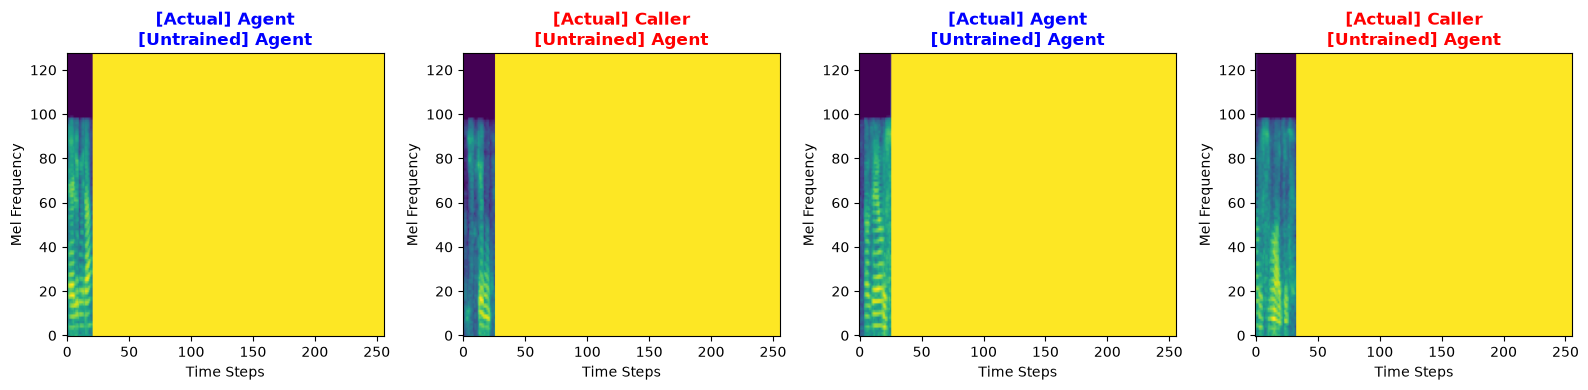

In [9]:
print("========== [학습 전] 모델의 찍기 결과 ==========")
show_predictions(model, test_batch_x, test_batch_y, title_prefix="Untrained")

## 🚀 2. 지도학습(Supervised Learning) 훈련시키기

AI에게 수만 장의 데이터를 보여주고, 정답과 틀렸을 때 가중치를 수정(Backpropagation)시킵니다.

In [ ]:
EPOCHS = 3 # 빨리 확인하기 위해 3번만 반복
LEARNING_RATE = 1e-4

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

for epoch in range(EPOCHS):
    model.train()
    epoch_loss = 0
    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{EPOCHS}')
    for batch_x, batch_y in progress_bar:
        batch_x = batch_x.to(device)
        batch_y = batch_y.to(device).unsqueeze(1)
        
        optimizer.zero_grad()
        y_pred = model(batch_x)
        loss = criterion(y_pred, batch_y)
        loss.backward()      # 여기서 가중치를 어느 방향으로 바꿀지 계산
        optimizer.step()     # 여기서 실제로 가중치(뇌세포)를 업데이트하여 더 똑똑해짐
        
        epoch_loss += loss.item()
        progress_bar.set_postfix({'Loss': loss.item()})

print("🎉 학습 완료!")

Epoch 1/3:   0%|          | 0/27286 [00:00<?, ?it/s]

c:\Users\user\Desktop\DCC\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1536
  warnings.warn(
c:\Users\user\Desktop\DCC\venv\Lib\site-packages\librosa\core\spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1888
  warnings.warn(


## ✨ 3. [학습 후] 똑똑해진 AI에게 똑같은 문제 다시 풀려보기

이제 훈련을 마친 AI에게 **아까 틀렸던 그 4문제**를 똑같이 다시 주어봅니다.
스펙트로그램 이미지의 특징(삐 소리, 잡음 등)을 완벽히 이해했다면 모두 <span style="color:blue">파란색 글씨(정답)</span>로 맞춰낼 것입니다!

In [ ]:
print("========== [학습 후] 모델의 정답 예측 결과 ==========")
show_predictions(model, test_batch_x, test_batch_y, title_prefix="Trained AI")